In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os, time, random, json
import numpy as np
import urllib.request, zipfile

# Silence TF info / warning messages; keep only errors.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping # ReduceLROnPlateau, 

# ─────────────────────────────────────────────────────────────────────────────
#  0. REPRODUCIBILITY
#     Fix all random seeds so results are reproducible across runs.
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─────────────────────────────────────────────────────────────────────────────
#  1. CONFIGURATION
#     Central dictionary – change values here; nothing else needs editing.
# ─────────────────────────────────────────────────────────────────────────────
CFG = {
    "num_classes":      46,      # DHCD: 36 consonants + 10 digits
    "image_size":       32,      # resize every image to 64×64 px
    "batch_size":       64,
    "epochs":           100,
    "lr":               5e-4,    # peak learning rate for cosine schedule
    "weight_decay":     1e-4,    # AdamW L2 regularisation
    "label_smoothing":  0.1,     # prevents over-confident softmax outputs
    "val_split":        0.1,     # fraction of training data held for validation
    # "data_dir":         "./data/DHCD",
    "data_dir":         "/kaggle/input/datasets/theranjitraut/devanagari/DevanagariHandwrittenCharacterDataset",
    "results_dir":      "./results",
}

os.makedirs(CFG["results_dir"], exist_ok=True)
NUM_CLASSES = CFG["num_classes"]
IMG         = CFG["image_size"]
BS          = CFG["batch_size"]
AUTOTUNE    = tf.data.AUTOTUNE


# ─────────────────────────────────────────────────────────────────────────────
#  2. DATASET DOWNLOAD & PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

# _DHCD_URL = (
#     "https://archive.ics.uci.edu/ml/machine-learning-databases/"
#     "00389/DevanagariHandwrittenCharacterDataset.zip"
# )

# import time
# import urllib.request
# from urllib.error import HTTPError

# url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
#     "00389/DevanagariHandwrittenCharacterDataset.zip")

# for i in range(5):  # retry up to 5 times
#     try:
#         response = urllib.request.urlopen(url)
#         data = response.read()
#         break  # success: exit loop
#     except HTTPError as e:
#         if e.code == 502:
#             print(f"502 Bad Gateway, retrying... attempt {i+1}/5")
#             time.sleep(2 ** i)  # exponential backoff
#         else:
#             raise  # other HTTP errors: re‑raise
            
# os.makedirs("./data", exist_ok=True)
# zip_path = "./data/DHCD.zip"
zip_path = "/kaggle/input/datasets/theranjitraut/devanagari/DevanagariHandwrittenCharacterDataset"
# ok = True  # True → real dataset loaded; False → synthetic fallback

if os.path.exists(CFG["data_dir"]):
    print("[INFO] DHCD already present – skipping download.")
else:
    print("[INFO] Downloading DHCD …")
    try:
        # urllib.request.urlretrieve(_DHCD_URL, zip_path)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall("./data/")
        os.rename("./data/DevanagariHandwrittenCharacterDataset", CFG["data_dir"])
        print("[INFO] DHCD extracted successfully.")
    except Exception as exc:
        print(f"[WARN] Download failed: {exc}")
        print("[INFO] Generating synthetic dataset for demonstration …")
        ok = False

# Synthetic fallback: random-noise grayscale PNGs so the pipeline still runs.
# if not ok:
#     from PIL import Image
#     for split in ["Train", "Test"]:
#         n_imgs = 200 if split == "Train" else 50
#         for c in range(NUM_CLASSES):
#             folder = os.path.join(CFG["data_dir"], split, f"character_{c+1:02d}")
#             os.makedirs(folder, exist_ok=True)
#             if len(os.listdir(folder)) >= 5:
#                 continue
#             for i in range(n_imgs):
#                 arr = np.random.randint(0, 256, (32, 32), dtype=np.uint8)
#                 Image.fromarray(arr, mode="L").save(
#                     os.path.join(folder, f"img_{i:04d}.png"))
#     print("[INFO] Synthetic dataset ready.")

# ── Load raw (unbatched) tf.data datasets ────────────────────────────────────
train_full = keras.utils.image_dataset_from_directory(
    os.path.join(CFG["data_dir"], "Train"),
    image_size=(IMG, IMG), batch_size=None,
    color_mode="grayscale", label_mode="int", seed=SEED,
)
test_ds_raw = keras.utils.image_dataset_from_directory(
    os.path.join(CFG["data_dir"], "Test"),
    image_size=(IMG, IMG), batch_size=None,
    color_mode="grayscale", label_mode="int", seed=SEED,
)

total   = tf.data.experimental.cardinality(train_full).numpy()
n_val   = max(1, int(total * CFG["val_split"]))
n_train = total - n_val

train_ds_raw = train_full.take(n_train)
val_ds_raw   = train_full.skip(n_train)

# ── Preprocessing helpers ─────────────────────────────────────────────────────

def normalise(img, lbl):
    """Scale pixels from [0, 255] → [-1, 1]."""
    img = tf.cast(img, tf.float32) / 127.5 - 1.0
    return img, lbl

def augment(img, lbl):
    """
    Light stochastic augmentation applied only during training.
    Pad-then-crop gives a random translation effect.
    """
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.pad(img, [[2, 2], [2, 2], [0, 0]], constant_values=-1.0)
    img = tf.image.random_crop(img, [IMG, IMG, 1])
    return img, lbl

def to_onehot(img, lbl):
    """
    Convert integer class index → one-hot vector.

    Required because keras.losses.CategoricalCrossentropy expects one-hot
    targets, while SparseCategoricalCrossentropy does NOT support the
    label_smoothing argument.
    """
    return img, tf.one_hot(lbl, NUM_CLASSES)

# ── Build tf.data pipelines ───────────────────────────────────────────────────
train_ds = (
    train_ds_raw
    .map(normalise,  num_parallel_calls=AUTOTUNE)
    .map(augment,    num_parallel_calls=AUTOTUNE)
    .map(to_onehot,  num_parallel_calls=AUTOTUNE)
    .shuffle(8192, seed=SEED)
    .batch(BS)
    .prefetch(AUTOTUNE)
)
val_ds = (
    val_ds_raw
    .map(normalise,  num_parallel_calls=AUTOTUNE)
    .map(to_onehot,  num_parallel_calls=AUTOTUNE)
    .batch(BS)
    .prefetch(AUTOTUNE)
)
# Integer-label test set → used for manual macro-F1 calculation.
test_ds = (
    test_ds_raw
    .map(normalise, num_parallel_calls=AUTOTUNE)
    .batch(BS)
    .prefetch(AUTOTUNE)
)
# One-hot test set → used for model.evaluate() (loss + accuracy).
test_ds_oh = (
    test_ds_raw
    .map(normalise,  num_parallel_calls=AUTOTUNE)
    .map(to_onehot,  num_parallel_calls=AUTOTUNE)
    .batch(BS)
    .prefetch(AUTOTUNE)
)

print(f"[INFO] Train: {n_train:,} | Val: {n_val:,} | Test: (batched)")


# ─────────────────────────────────────────────────────────────────────────────
#  3. DISPLAY UTILITIES
#     Rich terminal output: parameter tables and per-epoch progress bars.
# ─────────────────────────────────────────────────────────────────────────────

# ANSI colour codes (fall back gracefully on Windows terminals without VT mode)
_COL = {
    "reset":  "\033[0m",
    "bold":   "\033[1m",
    "cyan":   "\033[96m",
    "yellow": "\033[93m",
    "green":  "\033[92m",
    "red":    "\033[91m",
    "grey":   "\033[90m",
    "white":  "\033[97m",
    "blue":   "\033[94m",
}

def _c(text, *codes):
    """Wrap text in one or more ANSI codes."""
    prefix = "".join(_COL.get(c, "") for c in codes)
    return f"{prefix}{text}{_COL['reset']}"


def print_model_summary(model: Model) -> None:
    """
    Print a compact parameter table for a Keras model.
    Groups layers by trainable / non-trainable and shows totals.

    Example output
    ──────────────
    ╔══════════════════════════════════════════════════╗
    ║  our_model-Net  –  Parameter Summary             ║
    ╠══════════════╦═══════════════╦════════════════╣
    ║  Layer        ║  Type         ║  Parameters    ║
    ╠══════════════╬═══════════════╬════════════════╣
    ║  ...          ║  Conv2D       ║         1,152  ║
    ╠══════════════╩═══════════════╩════════════════╣
    ║  Trainable params           :       1,234,567  ║
    ║  Non-trainable params       :          12,345  ║
    ║  Total params               :       1,246,912  ║
    ╚═══════════════════════════════════════════════╝
    """
    W = 62   # table width
    sep = "─" * W

    trainable     = model.count_params()
    non_trainable = sum(
        tf.size(w).numpy() for w in model.non_trainable_weights
    )
    total = trainable + non_trainable

    # Header
    title = f"  {model.name}  –  Parameter Summary"
    print(f"\n{_c('╔' + '═'*W + '╗', 'cyan')}")
    print(_c(f"║{title:<{W}}║", "cyan", "bold"))
    print(_c(f"╠{'═'*18}╦{'═'*23}╦{'═'*18}╣", "cyan"))
    hdr = f"║  {'Layer':<16}║  {'Type':<21}║  {'Params':>15}  ║"
    print(_c(hdr, "cyan", "bold"))
    print(_c(f"╠{'═'*18}╬{'═'*23}╬{'═'*18}╣", "cyan"))

    # Up to 20 layers to keep output compact
    shown_layers = [l for l in model.layers if l.count_params() > 0][:20]
    for lyr in shown_layers:
        n_params = lyr.count_params()
        row = f"║  {lyr.name[:14]:<16}║  {type(lyr).__name__[:21]:<21}║  {n_params:>15,}  ║"
        print(row)
    if len([l for l in model.layers if l.count_params() > 0]) > 20:
        print(f"║  {'… (truncated)':<16}║  {'':21}║  {'':>15}  ║")

    # Totals footer
    print(_c(f"╠{'═'*18}╩{'═'*23}╩{'═'*18}╣", "cyan"))
    print(_c(f"║  {'Trainable params':<38}: {trainable:>18,}  ║", "green"))
    print(_c(f"║  {'Non-trainable params':<38}: {non_trainable:>18,}  ║", "grey"))
    print(_c(f"║  {'Total params':<38}: {total:>18,}  ║", "bold", "white"))
    print(_c(f"╚{'═'*W}╝", "cyan"))


class EpochProgressCallback(keras.callbacks.Callback):
    """
    Custom Keras callback that prints a compact, colourful progress bar
    after each epoch.

    Output per epoch:
      Epoch  3/50 ████████████░░░░░░░░  60%  loss=0.3412  acc=88.54%  val_acc=85.21%
    """

    BAR_WIDTH = 20  # character width of the filled progress bar

    def __init__(self, total_epochs: int, model_name: str):
        super().__init__()
        self.total_epochs = total_epochs
        self.model_name   = model_name
        self._epoch_start = 0.0

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs        = logs or {}
        elapsed     = time.time() - self._epoch_start
        ep_num      = epoch + 1
        pct         = ep_num / self.total_epochs
        filled      = int(self.BAR_WIDTH * pct)
        bar         = "█" * filled + "░" * (self.BAR_WIDTH - filled)

        loss    = logs.get("loss",     float("nan"))
        acc     = logs.get("accuracy", float("nan")) * 100
        val_acc = logs.get("val_accuracy", float("nan")) * 100
        val_los = logs.get("val_loss", float("nan"))

        # Retrieve current LR from the optimiser (works for schedule + float)
        try:
            lr_val = float(
                keras.backend.get_value(self.model.optimizer.learning_rate)
            )
            lr_str = f"lr={lr_val:.2e}"
        except Exception:
            lr_str = ""

        epoch_str  = _c(f"Epoch {ep_num:>3}/{self.total_epochs}", "grey")
        bar_str    = _c(bar, "cyan")
        pct_str    = _c(f"{pct*100:>5.1f}%", "yellow")
        loss_str   = _c(f"loss={loss:.4f}", "white")
        acc_str    = _c(f"acc={acc:.2f}%", "green")
        vl_str     = _c(f"val_loss={val_los:.4f}", "white")
        va_str     = _c(f"val_acc={val_acc:.2f}%", "yellow" if val_acc < acc else "green")
        time_str   = _c(f"[{elapsed:.1f}s]", "grey")
        lr_colored = _c(lr_str, "blue")

        print(
            f"  {epoch_str}  {bar_str} {pct_str}  "
            f"{loss_str}  {acc_str}  {vl_str}  {va_str}  "
            f"{lr_colored}  {time_str}"
        )


def print_comparison_table(results: dict) -> None:
    """
    Print a final side-by-side results table for all trained models.

    Highlights the winning model in green.
    """
    W   = 70
    best_name = max(results, key=lambda k: results[k]["test_acc"])

    print(f"\n{_c('╔' + '═'*W + '╗', 'cyan', 'bold')}")
    title = "  FINAL TEST-SET COMPARISON"
    print(_c(f"║{title:<{W}}║", "cyan", "bold"))
    print(_c(f"╠{'═'*24}╦{'═'*12}╦{'═'*12}╦{'═'*12}╦{'═'*6}╣", "cyan"))
    hdr = f"║  {'Model':<22}║{'Params':>11} ║{'Test Acc':>11} ║{'Macro F1':>11} ║{'Loss':>5} ║"
    print(_c(hdr, "bold", "white"))
    print(_c(f"╠{'═'*24}╬{'═'*12}╬{'═'*12}╬{'═'*12}╬{'═'*6}╣", "cyan"))

    for name, r in results.items():
        is_best = (name == best_name)
        color   = "green" if is_best else "white"
        star    = "★" if is_best else " "
        row = (
            f"║{star} {name:<22}║{r['params']:>10,} ║"
            f"{r['test_acc']:>10.2f}%║{r['macro_f1']:>10.2f}%║"
            f"{r['test_loss']:>5.3f} ║"
        )
        print(_c(row, color, "bold") if is_best else row)

    print(_c(f"╚{'═'*24}╩{'═'*12}╩{'═'*12}╩{'═'*12}╩{'═'*6}╝", "cyan"))
    print(_c(f"\n  ★  Winner: {best_name}  ({results[best_name]['test_acc']:.2f}% test accuracy)\n", "green", "bold"))


# ─────────────────────────────────────────────────────────────────────────────
#  4. BUILDING BLOCKS
#     Shared sub-modules used by our_model-Net.
# ─────────────────────────────────────────────────────────────────────────────

def gelu(x):
    """gelu activation – smoother than gelu, better gradients in deep nets."""
    return tf.nn.gelu(x)


def residual_block(x, channels: int):
    """
    Standard pre-activation residual block.
      Conv → BN → gelu → Conv → BN → Add(skip) → gelu
    No channel projection needed because in_channels == out_channels.
    """
    residual = x
    x = layers.Conv2D(channels, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(gelu)(x)
    x = layers.Conv2D(channels, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, residual])
    x = layers.Activation(gelu)(x)
    return x


def dense_res_block(x, in_channels: int, out_channels: int):
    """
    DenseNet-inspired residual block.

    Runs three sequential residual blocks and concatenates their outputs
    (dense connection), then projects back to out_channels via 1×1 conv.
    A strided depthwise conv at the end halves the spatial resolution
    (acts as a learned downsampling, replacing MaxPool).

    If in_channels ≠ out_channels, a learned projection aligns dimensions
    before the first residual block.
    """
    # ── Optional projection ───────────────────────────────────────────────
    if in_channels != out_channels:
        skip = layers.Conv2D(out_channels, 1, use_bias=False)(x)
        skip = layers.BatchNormalization()(skip)
        x_in = layers.Activation(gelu)(skip)
    else:
        x_in = x

    # ── Three chained residual blocks (dense connections) ─────────────────
    r1  = residual_block(x_in, out_channels)
    r2  = residual_block(r1,   out_channels)
    # r3  = residual_block(r2,   out_channels)
    cat = layers.Concatenate()([r1, r2])       #r3 # dense concat

    # ── Bottleneck projection back to out_channels ────────────────────────
    out = layers.Conv2D(out_channels, 1, use_bias=False)(cat)
    out = layers.BatchNormalization()(out)
    out = layers.Activation(gelu)(out)

    # ── Spatial downsampling via stride-2 depthwise conv ─────────────────
    out = layers.DepthwiseConv2D(3, strides=2, padding="same", use_bias=False)(out)
    out = layers.Conv2D(out_channels, 1, use_bias=False)(out)
    out = layers.BatchNormalization()(out)
    out = layers.Activation(gelu)(out)
    return out


def channel_attention(x, channels: int, reduction: int = 8):
    """
    Squeeze-and-Excitation (SE) channel attention.

    Computes per-channel importance weights via global average pooling
    followed by a two-layer MLP, then re-scales each channel accordingly.
    reduction controls the bottleneck size in the MLP.
    """
    gap  = layers.GlobalAveragePooling2D(keepdims=True)(x)
    gap  = layers.Reshape((channels,))(gap)
    attn = layers.Dense(channels // reduction, activation="gelu")(gap)
    attn = layers.Dense(channels, activation="sigmoid")(attn)
    attn = layers.Reshape((1, 1, channels))(attn)
    return layers.Multiply()([x, attn])


def adaptive_filter_capsule(x, num_classes: int, capsule_dim: int = 16):
    """
    Lightweight capsule-like routing module.

    Projects the feature vector into a (num_classes × capsule_dim) tensor,
    then uses the original feature as a per-class filter and sums to produce
    class-discriminative logit-like scores.  No dynamic routing – O(n) cost.
    """
    h = layers.Dense(256, activation=gelu)(x)
    h = layers.Dense(num_classes * capsule_dim)(h)
    h = layers.Reshape((num_classes, capsule_dim))(h)

    # Broadcast original features across classes and slice to capsule_dim
    x_exp    = layers.RepeatVector(num_classes)(x)
    x_sliced = layers.Lambda(lambda t: t[:, :, :capsule_dim])(x_exp)

    # Element-wise filter + sum-pool over the capsule dimension
    caps = layers.Multiply()([x_sliced, h])
    caps = layers.Lambda(lambda t: tf.reduce_sum(t, axis=-1))(caps)
    caps = layers.BatchNormalization()(caps)
    return caps


def stroke_topology_module(x, out_features: int):
    """
    Devanagari-specific stroke topology encoder.

    Uses asymmetric kernels (1×7, 7×1) to capture horizontal and vertical
    strokes, complemented by two parallel dilated convolutions (rate 1 and 2)
    for local and semi-local context.  The four feature maps are concatenated,
    pooled, and projected to a fixed-size vector.
    """
    h  = layers.Conv2D(64, (1, 5), padding="same", use_bias=False, activation=gelu)(x)
    v  = layers.Conv2D(64, (5, 1), padding="same", use_bias=False, activation=gelu)(x)
    d1 = layers.Conv2D(32, 3, padding="same", dilation_rate=1, use_bias=False, activation=gelu)(x)
    d2 = layers.Conv2D(32, 3, padding="same", dilation_rate=2, use_bias=False, activation=gelu)(x)
    out = layers.Concatenate()([h, v, d1, d2])
    out = layers.BatchNormalization()(out)
    out = layers.GlobalAveragePooling2D()(out)
    out = layers.Dense(out_features, activation=gelu)(out)
    return out


def cross_scale_transformer_bridge(s1, s2, s3, dim: int = 256, num_heads: int = 4):
    """
    Cross-scale transformer bridge (CSTB).

    Accepts three feature maps at different spatial scales (output of enc1,
    enc2, enc3), pools each to a single token, and applies multi-head
    self-attention across the three tokens.  This lets the model attend to
    fine-grained (s1) and coarse (s3) features simultaneously.
    The output is averaged across the three tokens and projected to dim.
    """
    # Pool each scale to a single d-dimensional token
    t1 = layers.Dense(dim, activation=gelu)(layers.GlobalAveragePooling2D()(s1))[:, tf.newaxis, :]
    t2 = layers.Dense(dim, activation=gelu)(layers.GlobalAveragePooling2D()(s2))[:, tf.newaxis, :]
    t3 = layers.Dense(dim, activation=gelu)(layers.GlobalAveragePooling2D()(s3))[:, tf.newaxis, :]

    seq      = layers.Concatenate(axis=1)([t1, t2, t3])          # (B, 3, dim)
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim // num_heads)(seq, seq)
    attn_out = layers.LayerNormalization()(attn_out + seq)        # residual + LN

    pooled = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1))(attn_out)
    pooled = layers.Dense(dim, activation=gelu)(pooled)
    return pooled


# ─────────────────────────────────────────────────────────────────────────────
#  5. MODEL DEFINITIONS
# ─────────────────────────────────────────────────────────────────────────────

def build_our_model_net(num_classes: int = 46, image_size: int = 32,
    drop_path_rate: float = 0.05,
    dropout_rate: float = 0.3,
    weight_decay: float = 1e-4,
    head_units: int = 256,
    override_tier: int = None,) -> Model:
    """
    our_model-Net: custom architecture for Devanagari recognition.

    Architecture overview
    ─────────────────────
    Stem (dual-path):
      • Standard 3×3 conv path
      • Horizontal stroke scaffold (1×7 conv)
      → Concatenated and refined with channel attention

    Encoder (3 stages, each halving spatial dims):
      enc1: 64→64    (32×32)
      enc2: 64→128   (16×16)
      enc3: 128→256  ( 8× 8)
      Each encoder stage adds a weighted scaffold residual for continuity.

    Decoder head:
      • Cross-scale transformer bridge (CSTB) fuses multi-scale context
      • Adaptive filter capsule (AFC) produces class-discriminative scores
      • Stroke topology module (STM) captures stroke/topology features
      • Gated fusion: learnable soft gate blends STM and AFC streams
      • Final MLP + layer norm → logits
    """
    K = num_classes

    inp = Input(shape=(image_size, image_size, 1), name="input")

    # ── Stem ──────────────────────────────────────────────────────────────
    # Texture path: standard 3×3 convolution
    t        = layers.Conv2D(32, 3, padding="same", use_bias=False)(inp)
    t        = layers.BatchNormalization()(t)
    t        = layers.Activation(gelu)(t)

    # Stroke scaffold: horizontal asymmetric convolution (captures Devanagari
    # top-bar "shirorekha" and horizontal stroke components)
    s        = layers.Conv2D(32, (1, 5), padding="same", use_bias=False)(inp)
    s        = layers.BatchNormalization()(s)
    scaffold  = layers.Activation(gelu)(s)

    stem = layers.Concatenate()([t, scaffold])
    stem = channel_attention(stem, 64)          # SE re-weighting
    stem = layers.Conv2D(64, 1, use_bias=False)(stem)
    stem = layers.BatchNormalization()(stem)
    stem = layers.Activation(gelu)(stem)

    # ── Encoder ───────────────────────────────────────────────────────────
    # Each encoder stage is a dense residual block + scaffold injection.
    # Scaffold is pooled to match the encoder's spatial resolution and
    # added with a small learnable weight (0.1) to preserve stroke structure.

    enc1 = dense_res_block(stem, 64, 64)
    sc1  = layers.AveragePooling2D(2)(layers.Conv2D(64, 1, use_bias=False)(scaffold))
    enc1 = layers.Add()([enc1, layers.Lambda(lambda t: t * 0.1)(sc1)])

    enc2 = dense_res_block(enc1, 64, 128)
    sc2  = layers.AveragePooling2D(4)(layers.Conv2D(128, 1, use_bias=False)(scaffold))
    enc2 = layers.Add()([enc2, layers.Lambda(lambda t: t * 0.1)(sc2)])

    enc3 = dense_res_block(enc2, 128, 256)
    sc3  = layers.AveragePooling2D(8)(layers.Conv2D(256, 1, use_bias=False)(scaffold))
    enc3 = layers.Add()([enc3, layers.Lambda(lambda t: t * 0.1)(sc3)])

    # # ── Decoder head ──────────────────────────────────────────────────────
    # # CSTB: cross-scale self-attention across enc1/enc2/enc3 tokens
    # cstb_out = cross_scale_transformer_bridge(enc1, enc2, enc3, dim=256)

    # # AFC: capsule-based class routing applied to the pooled enc3 + CSTB sum
    # afc_in  = layers.GlobalAveragePooling2D()(enc3)
    # afc_in  = layers.Add()([afc_in, cstb_out])
    # afc_out = adaptive_filter_capsule(afc_in, K)          # (B, K)

    # # STM: stroke topology encoding from enc3 feature maps
    # stgm_out = stroke_topology_module(enc3, 256)           # (B, 256)

    # # Gated fusion: soft gate decides how much of STM vs AFC to use
    # combined    = layers.Concatenate()([stgm_out, afc_out])
    # gate        = layers.Dense(2, activation="softmax", name="gate")(combined)  # (B, 2)
    # stgm_scaled = layers.Lambda(lambda t: t[0] * t[1][:, 0:1])([stgm_out, gate])
    # fused       = layers.Concatenate()([stgm_scaled, afc_out])

    # # Final classification MLP
    # x   = layers.Dense(512)(fused)
    # x   = layers.LayerNormalization()(x)
    # x   = layers.Activation(gelu)(x)
    # out = layers.Dense(K, name="logits")(x)

    # return Model(inputs=inp, outputs=out, name="our_model-Net")


# # ── Multi-scale GAP fusion ──────────────────────────────────────────────
#     # Global average pool each encoder stage and concatenate
#     gap1 = layers.GlobalAveragePooling2D(name="gap1")(enc1)
#     gap2 = layers.GlobalAveragePooling2D(name="gap2")(enc2)
#     gap3 = layers.GlobalAveragePooling2D(name="gap3")(enc3)
#     fused = layers.Concatenate(name="multiscale_fused")([gap1, gap2, gap3])

#     # ── Classification head ─────────────────────────────────────────────────
#     # x = layers.Dense(head_units, use_bias=False, kernel_regularizer=regularizers.l2(weight_decay), name="head_dense")(fused)
#     x = layers.Dense(head_units, use_bias=False, name="head_dense")(fused)
#     x = layers.LayerNormalization(name="head_ln")(x)
#     x = layers.Activation("gelu", name="head_act")(x)
#     # x = layers.Dropout(dropout_rate, name="head_drop")(x)
#     outputs = layers.Dense(num_classes, name="logits")(x)

#     model = keras.Model(inputs=inp, outputs=outputs, name="our_model-Net")
#     return model

# ── Multi-scale GAP fusion ──────────────────────────────────────────────
    gap1 = layers.GlobalAveragePooling2D(name="gap1")(enc1)
    gap2 = layers.GlobalAveragePooling2D(name="gap2")(enc2)
    gap3 = layers.GlobalAveragePooling2D(name="gap3")(enc3)
    fused_gap = layers.Concatenate(name="multiscale_fused")([gap1, gap2, gap3])

    # ── Adaptive Filter Capsule (AFC) ───────────────────────────────────────
    # Projects the fused multi-scale vector into capsule space.
    # Each of the K capsules learns to respond to one character class.
    afc_out = adaptive_filter_capsule(fused_gap, num_classes)   # (B, K)

    # ── Classification head ─────────────────────────────────────────────────
    # Dense projection of the raw GAP features (residual path alongside AFC)
    x = layers.Dense(head_units, use_bias=False, name="head_dense")(fused_gap)
    x = layers.LayerNormalization(name="head_ln")(x)
    x = layers.Activation("gelu", name="head_act")(x)
    x = layers.Dense(num_classes, name="head_logits")(x)

    # ── Gated fusion: AFC scores + dense-head logits ────────────────────────
    # A learned scalar gate (per-sample softmax over 2 weights) blends the
    # AFC capsule scores with the plain dense logits.  This lets the model
    # learn how much to trust the capsule routing vs. the direct projection.
    combined = layers.Concatenate(name="gate_input")([x, afc_out])
    gate     = layers.Dense(2, activation="softmax", name="gate")(combined)  # (B, 2)

    # gate[:,0] weights the dense head; gate[:,1] weights the AFC output
    x_scaled   = layers.Lambda(
        lambda t: t[0] * t[1][:, 0:1], name="gate_dense")([x,gate])
    afc_scaled = layers.Lambda(
        lambda t: t[0] * t[1][:, 1:2], name="gate_afc"  )([afc_out,gate])

    outputs = layers.Add(name="logits")([x_scaled, afc_scaled])

    model = keras.Model(inputs=inp, outputs=outputs, name="our_model-Net")
    return model

# def build_mallanet_tf(num_classes: int = 46, image_size: int = 32) -> Model:
#     """
#     MallaNet (baseline).
#     Three stages of repeated residual blocks with MaxPool downsampling,
#     followed by a two-layer dense classifier.
#     """
#     K = num_classes
#     inp = Input(shape=(image_size, image_size, 1))

#     def mallanet_block(x, ch: int):
#         # 1×1 projection to ch channels
#         x = layers.Conv2D(ch, 1, use_bias=False)(x)
#         x = layers.BatchNormalization()(x)
#         x = layers.gelu()(x)
#         # 3 residual blocks at this channel depth
#         for _ in range(3):
#             r = x
#             x = layers.Conv2D(ch, 3, padding="same", use_bias=False)(x)
#             x = layers.BatchNormalization()(x); x = layers.gelu()(x)
#             x = layers.Conv2D(ch, 3, padding="same", use_bias=False)(x)
#             x = layers.BatchNormalization()(x)
#             x = layers.Add()([x, r]); x = layers.gelu()(x)
#         return layers.MaxPooling2D(2)(x)

#     x = mallanet_block(inp, 128)
#     x = mallanet_block(x,   256)
#     x = mallanet_block(x,   512)
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dense(K * 16)(x); x = layers.BatchNormalization()(x); x = layers.gelu()(x)
#     x = layers.Dense(K * 8)(x);  x = layers.BatchNormalization()(x); x = layers.gelu()(x)
#     x = layers.Dense(K)(x)
#     out = layers.Dense(K, name="logits")(x)
#     return Model(inp, out, name="MallaNet")


# def build_bmcnn_hvcs_tf(num_classes: int = 46, image_size: int = 64) -> Model:
#     """
#     BMCNNwHVCs – Branch-Merge CNN with Horizontal/Vertical Channel Splits.
#     A two-branch head (3×3 vs 1×1 conv) is merged before the classifier.
#     """
#     K = num_classes
#     inp = Input(shape=(image_size, image_size, 1))

#     x = layers.Conv2D(64,  3, padding="same", use_bias=False)(inp)
#     x = layers.BatchNormalization()(x); x = layers.gelu()(x)
#     x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
#     x = layers.BatchNormalization()(x); x = layers.gelu()(x)
#     x = layers.MaxPooling2D(2)(x)
#     x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
#     x = layers.BatchNormalization()(x); x = layers.gelu()(x)
#     x = layers.MaxPooling2D(2)(x)

#     # Two parallel branches
#     a = layers.Conv2D(256, 3, padding="same")(x); a = layers.gelu()(a)
#     a = layers.MaxPooling2D(2)(a); a = layers.GlobalAveragePooling2D()(a)

#     b = layers.Conv2D(256, 1)(x); b = layers.gelu()(b)
#     b = layers.MaxPooling2D(2)(b); b = layers.GlobalAveragePooling2D()(b)

#     x = layers.Concatenate()([a, b])
#     x = layers.Dense(K * 8)(x); x = layers.BatchNormalization()(x); x = layers.gelu()(x)
#     out = layers.Dense(K, name="logits")(x)
#     return Model(inp, out, name="BMCNNwHVCs")


# def build_resnet50_tf(num_classes: int = 46, image_size: int = 64) -> Model:
#     """ResNet-50 trained from scratch (no ImageNet weights)."""
#     inp = Input(shape=(image_size, image_size, 1))
#     # Expand grayscale → 3-channel for compatibility with ResNet-50.
#     x   = layers.Conv2D(3, 1, padding="same", use_bias=False)(inp)
#     base = keras.applications.ResNet50(
#         include_top=False, weights=None, input_tensor=x, pooling="avg")
#     out = layers.Dense(num_classes, name="logits")(base.output)
#     return Model(inp, out, name="ResNet-50")


# def build_efficientnet_b3_tf(num_classes: int = 46, image_size: int = 64) -> Model:
#     """EfficientNet-B3 trained from scratch (no ImageNet weights)."""
#     inp = Input(shape=(image_size, image_size, 1))
#     x   = layers.Conv2D(3, 1, padding="same", use_bias=False)(inp)
#     base = keras.applications.EfficientNetB3(
#         include_top=False, weights=None, input_tensor=x, pooling="avg")
#     out = layers.Dense(num_classes, name="logits")(base.output)
#     return Model(inp, out, name="EfficientNet-B3")


# def build_convnext_tiny_tf(num_classes: int = 46, image_size: int = 64) -> Model:
#     """
#     ConvNeXt-Tiny trained from scratch.
#     Falls back to a manual implementation if the Keras application is
#     not available (TF < 2.12).
#     """
#     inp = Input(shape=(image_size, image_size, 1))
#     x   = layers.Conv2D(3, 1, padding="same", use_bias=False)(inp)

#     try:
#         base = keras.applications.ConvNeXtTiny(
#             include_top=False, weights=None, input_tensor=x, pooling="avg")
#         out = layers.Dense(num_classes, name="logits")(base.output)
#     except AttributeError:
#         # Manual ConvNeXt-style fallback for older TF versions
#         x2 = layers.Conv2D(96, 4, strides=4, padding="same")(x)
#         x2 = layers.LayerNormalization()(x2)
#         for ch in [96, 192, 384, 768]:
#             x2 = layers.DepthwiseConv2D(7, padding="same")(x2)
#             x2 = layers.LayerNormalization()(x2)
#             x2 = layers.Dense(ch * 4)(x2)
#             x2 = layers.Activation("gelu")(x2)
#             x2 = layers.Dense(ch)(x2)
#             if x2.shape[-1] != ch:
#                 x2 = layers.Conv2D(ch, 1)(x2)
#         x2  = layers.GlobalAveragePooling2D()(x2)
#         out = layers.Dense(num_classes, name="logits")(x2)

#     return Model(inp, out, name="ConvNeXt-Tiny")


# Registry: model name → builder function (called lazily inside the training loop)
MODELS_TF = {
    "our_model-Net":    lambda: build_our_model_net(NUM_CLASSES, IMG),
    # "MallaNet":        lambda: build_mallanet_tf(NUM_CLASSES, IMG),
    # "BMCNNwHVCs":      lambda: build_bmcnn_hvcs_tf(NUM_CLASSES, IMG),
    # "ResNet-50":       lambda: build_resnet50_tf(NUM_CLASSES, IMG),
    # "EfficientNet-B3": lambda: build_efficientnet_b3_tf(NUM_CLASSES, IMG),
    # "ConvNeXt-Tiny":   lambda: build_convnext_tiny_tf(NUM_CLASSES, IMG),
}

# ─────────────────────────────────────────────────────────────────────────────
#  6. LR SCHEDULE
# ─────────────────────────────────────────────────────────────────────────────

class CosineAnnealing(keras.optimizers.schedules.LearningRateSchedule):
    """
    Cosine-annealing schedule without restarts.

    LR decays from `base` to a floor of 1e-6 following a half-cosine curve
    over `steps` optimizer steps.

    Formula:  lr(t) = max(base * 0.5 * (1 + cos(π·t/T)), 1e-6)
    """

    def __init__(self, base: float, steps: int):
        self.base  = base
        self.steps = tf.cast(steps, tf.float32)

    def __call__(self, step):
        step   = tf.cast(step, tf.float32)
        cosine = 0.5 * (1.0 + tf.cos(np.pi * step / self.steps))
        return tf.maximum(self.base * cosine, 1e-6)

    def get_config(self):
        return {"base": self.base, "steps": int(self.steps)}


# ─────────────────────────────────────────────────────────────────────────────
#  7. TRAINING & EVALUATION HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def compile_model(model: Model, steps_total: int) -> Model:
    """
    Attach optimiser, loss, and metrics to a model.

    Uses AdamW (L2-regularised Adam) with a cosine-annealing LR schedule.
    CategoricalCrossentropy (with from_logits=True) is paired with label
    smoothing to improve calibration and reduce overfitting.
    """
    lr_sch = CosineAnnealing(CFG["lr"], steps_total)
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=lr_sch,
            weight_decay=CFG["weight_decay"],
        ),
        loss=keras.losses.CategoricalCrossentropy(
            from_logits=True,
            label_smoothing=CFG["label_smoothing"],
        ),
        metrics=["accuracy"],
        jit_compile=True
    )
    return model


def compute_macro_f1(model: Model, dataset) -> float:
    """
    Compute macro-averaged F1 score over all NUM_CLASSES classes.

    dataset must yield (images, integer_labels) batches.
    Returns F1 as a percentage (0–100).
    """
    tp = np.zeros(NUM_CLASSES)
    fp = np.zeros(NUM_CLASSES)
    fn = np.zeros(NUM_CLASSES)

    for images, labels in dataset:
        preds = tf.argmax(model(images, training=False), axis=1).numpy()
        lbls  = labels.numpy()
        for c in range(NUM_CLASSES):
            tp[c] += np.sum((preds == c) & (lbls == c))
            fp[c] += np.sum((preds == c) & (lbls != c))
            fn[c] += np.sum((preds != c) & (lbls == c))

    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    return float(f1.mean() * 100.0)


# ─────────────────────────────────────────────────────────────────────────────
#  8. TRAIN + EVALUATE ALL MODELS
# ─────────────────────────────────────────────────────────────────────────────

trained_models  = {}
all_histories   = {}
steps_per_epoch = sum(1 for _ in train_ds)   # number of batches per epoch
total_steps     = steps_per_epoch * CFG["epochs"]

print(_c(f"\n{'═'*70}", "cyan"))
print(_c(f"  Starting benchmark: {len(MODELS_TF)} models × {CFG['epochs']} epochs", "bold", "white"))
print(_c(f"{'═'*70}\n", "cyan"))

for name, model_fn in MODELS_TF.items():
    # Build a fresh model for each experiment
    model = model_fn()
    model = compile_model(model, total_steps)

    # Print the compact parameter table before training starts
    print_model_summary(model)

    # Checkpoint saves the best val_accuracy weights during training
    ckpt_path = os.path.join(CFG["results_dir"], f"{name}_best.keras")
    callbacks = [
        ModelCheckpoint(
            ckpt_path, monitor="val_accuracy",
            save_best_only=True, verbose=0,
        ),
        # ReduceLROnPlateau(
        #     monitor="val_loss", factor=0.5,
        #     patience=5, min_lr=1e-6, verbose=0,
        # ),
        EarlyStopping(
            monitor="val_accuracy", patience=15,
            restore_best_weights=True, verbose=0,
        ),
        # Our custom progress bar – replaces the default Keras bar
        # EpochProgressCallback(CFG["epochs"], name),
    ]

    print(f"\n{_c('  ▶ Training:', 'bold', 'cyan')} {_c(name, 'yellow')}")

    t0 = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CFG["epochs"],
        callbacks=callbacks,
        verbose=1,          # suppress default Keras output; use our callback
    )
    elapsed  = time.time() - t0
    best_val = max(history.history["val_accuracy"]) * 100.0

    print(
        f"\n  {_c('✔ Done:', 'green', 'bold')} "
        f"best val acc = {_c(f'{best_val:.2f}%', 'green')}  "
        f"wall time = {_c(f'{elapsed:.0f}s', 'grey')}"
    )

    trained_models[name] = model
    all_histories[name]  = history.history

2026-04-24 05:58:36.332295: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777010316.556423      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777010316.621408      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777010317.150240      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777010317.150283      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777010317.150286      55 computation_placer.cc:177] computation placer alr

[INFO] DHCD already present – skipping download.
Found 78200 files belonging to 46 classes.


I0000 00:00:1777010409.285013      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777010409.291007      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 13800 files belonging to 46 classes.
[INFO] Train: 70,380 | Val: 7,820 | Test: (batched)

══════════════════════════════════════════════════════════════════════
  Starting benchmark: 1 models × 100 epochs
══════════════════════════════════════════════════════════════════════


╔══════════════════════════════════════════════════════════════╗
║  our_model-Net  –  Parameter Summary                         ║
╠══════════════════╦═══════════════════════╦══════════════════╣
║  Layer           ║  Type                 ║           Params  ║
╠══════════════════╬═══════════════════════╬══════════════════╣
║  conv2d          ║  Conv2D               ║              288  ║
║  conv2d_1        ║  Conv2D               ║              160  ║
║  batch_normaliz  ║  BatchNormalization   ║              128  ║
║  batch_normaliz  ║  BatchNormalization   ║              128  ║
║  dense           ║  Dense                ║              520  ║
║  dense_1         ║  Dense                ║              576  ║
║  

I0000 00:00:1777010629.476068     132 service.cc:152] XLA service 0x7a2004020110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777010629.476119     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777010629.476126     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777010632.668642     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777010650.565076     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1100/1100 ━━━━━━━━━━━━━━━━━━━━ 163s 112ms/step - accuracy: 0.6776 - loss: 1.8768 - val_accuracy: 0.9821 - val_loss: 0.8261
Epoch 2/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 88s 78ms/step - accuracy: 0.9725 - loss: 0.8783 - val_accuracy: 0.9749 - val_loss: 0.8345
Epoch 3/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 97s 86ms/step - accuracy: 0.9826 - loss: 0.8238 - val_accuracy: 0.9875 - val_loss: 0.7962
Epoch 4/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 95s 84ms/step - accuracy: 0.9886 - loss: 0.7884 - val_accuracy: 0.9877 - val_loss: 0.7714
Epoch 5/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 91s 80ms/step - accuracy: 0.9899 - loss: 0.7723 - val_accuracy: 0.9909 - val_loss: 0.7871
Epoch 6/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 90s 80ms/step - accuracy: 0.9922 - loss: 0.7565 - val_accuracy: 0.9921 - val_loss: 0.7468
Epoch 7/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 90s 79ms/step - accuracy: 0.9929 - loss: 0.7462 - val_accuracy: 0.9936 - val_loss: 0.7375
Epoch 8/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 90s 80ms/step - accuracy: 0.9936 - l

In [3]:
#  9. FINAL TEST-SET EVALUATION
results = {}

for name, model in trained_models.items():
    test_loss, test_acc_raw = model.evaluate(test_ds_oh, verbose=0)
    test_acc = test_acc_raw * 100.0
    macro_f1 = compute_macro_f1(model, test_ds)   # integer-label dataset
    results[name] = {
        "test_acc":  round(test_acc, 2),
        "macro_f1":  round(macro_f1, 2),
        "params":    model.count_params(),
        "test_loss": round(float(test_loss), 4),
    }

# Comparison table
print_comparison_table(results)


╔══════════════════════════════════════════════════════════════════════╗
║  FINAL TEST-SET COMPARISON                                           ║
╠════════════════════════╦════════════╦════════════╦════════════╦══════╣
║  Model                 ║     Params ║   Test Acc ║   Macro F1 ║ Loss ║
╠════════════════════════╬════════════╬════════════╬════════════╬══════╣
║★ our_model-Net         ║ 3,863,880 ║     99.75%║     99.75%║0.703 ║
╚════════════════════════╩════════════╩════════════╩════════════╩══════╝

  ★  Winner: our_model-Net  (99.75% test accuracy)



In [13]:
def compute_score(model: Model, dataset) -> float:
    """
    Compute macro-averaged F1 score over all NUM_CLASSES classes.

    dataset must yield (images, integer_labels) batches.
    Returns F1 as a percentage (0–100).
    """
    tp = np.zeros(NUM_CLASSES)
    fp = np.zeros(NUM_CLASSES)
    fn = np.zeros(NUM_CLASSES)

    for images, labels in dataset:
        preds = tf.argmax(model(images, training=False), axis=1).numpy()
        lbls  = labels.numpy()
        for c in range(NUM_CLASSES):
            tp[c] += np.sum((preds == c) & (lbls == c))
            fp[c] += np.sum((preds == c) & (lbls != c))
            fn[c] += np.sum((preds != c) & (lbls == c))

    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    print(f"Precision: {float(prec.mean() * 100.0)}, Recall: {float(rec.mean() * 100.0)}, F1: {float(f1.mean() * 100.0)}")
compute_score(model, test_ds)

Precision: 99.75488878842664, Recall: 99.7536231850807, F1: 99.7537034251347


In [12]:
import numpy as np
import tensorflow as tf

def compute_confusion_matrix(model: Model, dataset, NUM_CLASSES):
    """
    Compute and return confusion matrix from dataset predictions.
    Shape: (NUM_CLASSES, NUM_CLASSES) where rows=actual, cols=predicted.
    """
    tp = np.zeros(NUM_CLASSES)
    fp = np.zeros(NUM_CLASSES) 
    fn = np.zeros(NUM_CLASSES)
    
    # Also track total predictions per class for confusion matrix
    conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))
    
    for images, labels in dataset:
        preds = tf.argmax(model(images, training=False), axis=1).numpy()
        lbls = labels.numpy()
        
        for i in range(len(preds)):
            actual = lbls[i]
            pred = preds[i]
            conf_matrix[actual, pred] += 1  # Direct count
            
            # Your original TP/FP/FN logic (for verification)
            for c in range(NUM_CLASSES):
                if pred == c and actual == c:
                    tp[c] += 1
                elif pred == c and actual != c:
                    fp[c] += 1
                elif pred != c and actual == c:
                    fn[c] += 1
    
    # Verify: row sums should match actual class counts
    print("Confusion Matrix (rows=actual, cols=predicted):")
    print(conf_matrix.astype(int))
    
    # Original macro F1 output
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    print(f"Macro Prec: {prec.mean()*100:.1f}%, Rec: {rec.mean()*100:.1f}%, F1: {f1.mean()*100:.1f}%")
    
    return conf_matrix

# Usage
cm = compute_confusion_matrix(model, test_ds, NUM_CLASSES)

Confusion Matrix (rows=actual, cols=predicted):
[[300   0   0 ...   0   0   0]
 [  0 296   1 ...   0   1   0]
 [  0   0 300 ...   0   0   0]
 ...
 [  0   0   0 ... 300   0   0]
 [  0   0   0 ...   0 300   0]
 [  0   0   0 ...   0   0 300]]
Macro Prec: 99.8%, Rec: 99.8%, F1: 99.8%


Confusion Matrix (rows=actual, cols=predicted):
[[300   0   0 ...   0   0   0]
 [  0 296   1 ...   0   1   0]
 [  0   0 300 ...   0   0   0]
 ...
 [  0   0   0 ... 300   0   0]
 [  0   0   0 ...   0 300   0]
 [  0   0   0 ...   0   0 300]]
Macro Prec: 99.8%, Rec: 99.8%, F1: 99.8%


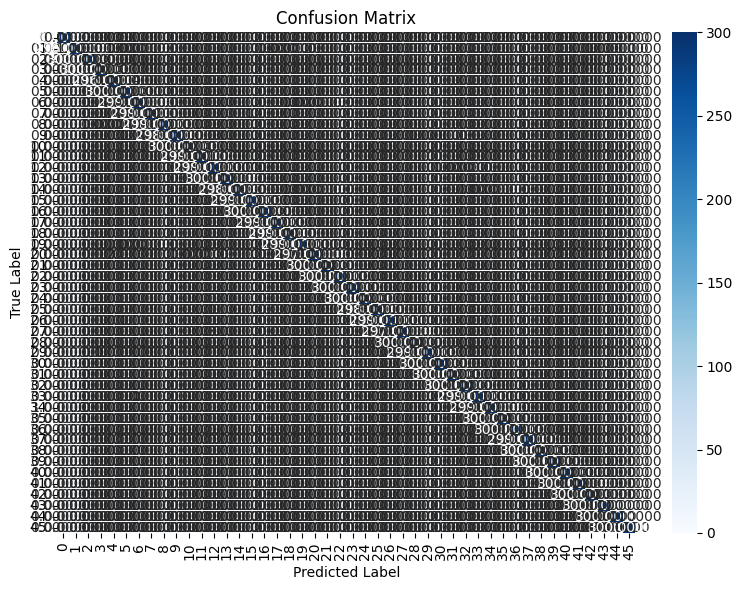

In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

def compute_confusion_matrix(model: tf.keras.Model, dataset, NUM_CLASSES):
    """
    Compute and return confusion matrix from dataset predictions.
    Shape: (NUM_CLASSES, NUM_CLASSES) where rows=actual, cols=predicted.
    Now includes matplotlib visualization.
    """
    tp = np.zeros(NUM_CLASSES)
    fp = np.zeros(NUM_CLASSES) 
    fn = np.zeros(NUM_CLASSES)
    
    # Track total predictions per class for confusion matrix
    conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))
    
    for images, labels in dataset:
        preds = tf.argmax(model(images, training=False), axis=1).numpy()
        lbls = labels.numpy()
        
        for i in range(len(preds)):
            actual = lbls[i]
            pred = preds[i]
            conf_matrix[actual, pred] += 1  # Direct count
            
            # Your original TP/FP/FN logic (for verification)
            for c in range(NUM_CLASSES):
                if pred == c and actual == c:
                    tp[c] += 1
                elif pred == c and actual != c:
                    fp[c] += 1
                elif pred != c and actual == c:
                    fn[c] += 1
    
    # Print confusion matrix
    print("Confusion Matrix (rows=actual, cols=predicted):")
    print(conf_matrix.astype(int))
    
    # Original macro F1 output
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    print(f"Macro Prec: {prec.mean()*100:.1f}%, Rec: {rec.mean()*100:.1f}%, F1: {f1.mean()*100:.1f}%")
    
    # MATPLOTLIB VISUALIZATION
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='f', cmap='Blues', 
                xticklabels=range(NUM_CLASSES), 
                yticklabels=range(NUM_CLASSES))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    # plt.savefig('output/confusion_matrix.png')  # Save to output/ for sharing
    plt.show()
    
    return conf_matrix

# Usage (save to output/ directory as required)
cm = compute_confusion_matrix(model, test_ds, NUM_CLASSES)

In [ ]:
#  10. PERSIST RESULTS
results_path = os.path.join(CFG["results_dir"], "tensorflow_results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"[INFO] Results  → {results_path}")

histories_path = os.path.join(CFG["results_dir"], "tensorflow_histories.json")
with open(histories_path, "w") as f:
    json.dump(
        {
            n: {k: [float(v) for v in vals] for k, vals in h.items()}
            for n, h in all_histories.items()
        },
        f, indent=2,
    )
print(f"[INFO] Histories → {histories_path}")

print(_c("\n[DONE] TensorFlow benchmark complete.\n", "green", "bold"))